In [19]:
import os
from dotenv import load_dotenv
from google.cloud import bigquery
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [20]:
load_dotenv

key_file_path = os.environ.get("GCP_KEY_PATH")

client = bigquery.Client.from_service_account_json(
    key_file_path,
    project="quantum-echo-data-eng-prod"
)

df_sales = client.query("SELECT product_key, gross_sales_amount FROM `quantum-echo-data-eng-prod.gold.fct_sales`").to_dataframe()
df_products = client.query("SELECT product_key, category FROM `quantum-echo-data-eng-prod.gold.dim_products`").to_dataframe()

category_sales = (
    df_sales.merge(df_products, on="product_key", how="left")
    .groupby("category", as_index=False)
    .agg(total_sales=("gross_sales_amount", "sum"))
    .assign(
        total_sales=lambda x: x["total_sales"].astype("int64"),
        percentage_of_total=lambda x: (
            (x['total_sales'] / x['total_sales'].sum() * 100)
            .round(2)
            .astype(str) + "%"
        )
        )
)

category_sales

,category,total_sales,percentage_of_total
0,Accessories,700209,2.39%
1,Bikes,28316272,96.46%
2,Clothing,339385,1.16%


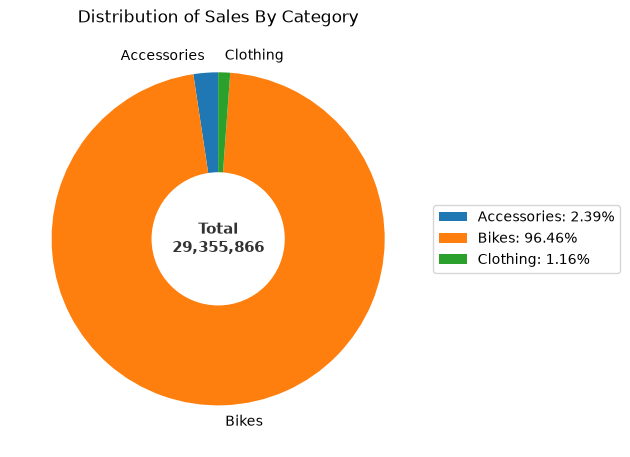

In [21]:
fig, ax = plt.subplots(figsize=(6,5))

# 1. Plot standard pie chart
category_sales.plot(
    y="total_sales",
    kind='pie',
    ax=ax,
    labels=category_sales['category'],
    legend=False,
    startangle=90

)

# 2. Add white circle for donut hole
centre_circle = plt.Circle((0, 0), 0.40, fc='white')
ax.add_artist(centre_circle)

# 3. Calculate total sales
total_revenue = category_sales['total_sales'].sum()

# 4. Add centered text inside the donut hole
ax.text(
    0, 0,                             # Coordinates: (x=0, y=0) is exact center
    f"Total\n{total_revenue:,.0f}",       # Main text string with line break
    ha='center',                       # Horizontal alignment
    va='center',                       # Vertical alignment
    fontsize=11, 
    fontweight='bold', 
    color='#333333'
)

legend_labels = [
    f"{cat}: {pct}" 
    for cat, pct in zip(category_sales['category'], category_sales['percentage_of_total'])
]

ax.legend(legend_labels, loc="center left", bbox_to_anchor=(1, 0.5))

ax.set_ylabel('')
ax.set_title("Distribution of Sales By Category")

plt.tight_layout()
plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")
plt.show()
